 ## Master in Artificial Intelligence, USC, UDC, UVigo. 2025/2026
## COMPUTER VISION I
## Lab 6: Feature Matching with SIFT

## Introduction to SIFT

Feature matching refers to the process of finding corresponding keypoints between two images of the same scene or object. The **Scale-Invariant Feature Transform (SIFT)** algorithm is one of the most robust methods for detecting and describing local features in images.

SIFT keypoints are distinctive image features such as corners, edges, and blobs that can be reliably identified across different:
- Scales (zoom levels)
- Rotations
- Illumination changes
- Viewpoint variations (within limits)

### SIFT Algorithm Pipeline

1. **Scale-space extrema detection**: Build a Gaussian pyramid and Difference of Gaussians (DoG), then find local extrema
2. **Keypoint localization**: Refine keypoint locations and filter unstable points
3. **Orientation assignment**: Compute dominant gradient orientation for rotation invariance
4. **Descriptor extraction**: Create 128-dimensional feature vector describing local image structure

![SIFT](sift.png)

## Setup

Import required libraries and visualization utilities.

In [1]:
import cv2
from cv2 import GaussianBlur,resize, INTER_NEAREST
from matplotlib import pyplot as plt
import numpy as np

# Import visualization utilities
from lab6_utils import (
    plot_gaussian_pyramid,
    visualize_all_dog_levels,
    visualize_keypoints,
    visualize_keypoints_with_orientation,
    compare_matching_with_opencv,
    descriptor_exercise_with_gradients,
    apply_rotation, apply_scale, apply_brightness,
    apply_noise, apply_blur,
    visualize_transformations_custom,
    test_sift_robustness_with_opencv_custom
)

# Load test image
building = cv2.imread('building-600by600.tif', cv2.IMREAD_GRAYSCALE)

print(f"Loaded image: {building.shape}")

Loaded image: (600, 600)


In [ ]:
def computeHistogram(magnitude, orientation, x, y, radius, num_bins, reference_angle=0):
    """
    Build histogram of gradient orientations in a window.
    
    Args:
        magnitude: Gradient magnitude image
        orientation: Gradient orientation image (degrees)
        x, y: Center point coordinates
        radius: Window radius in pixels
        num_bins: Number of orientation bins (typically 36 or 8)
        reference_angle: Angle to subtract from all orientations (for rotation invariance)
    
    Returns:
        np.array: Histogram of length num_bins
    """
    hist = np.zeros(num_bins)
    bin_size = 360.0 / num_bins

    r = int(radius)
    x, y = int(x), int(y)

    for di in range(-r, r + 1):
        for dj in range(-r, r + 1):
            py, px = y + di, x + dj
            if 0 <= py < magnitude.shape[0] and 0 <= px < magnitude.shape[1]:
                mag = magnitude[py, px]
                angle = (orientation[py, px] - reference_angle) % 360
                bin_idx = int(angle / bin_size) % num_bins
                hist[bin_idx] += mag
    
    return hist

---
## Gaussian Pyramid Construction

### Background: Scale-Space Representation

To detect features at multiple scales, SIFT builds a **scale-space pyramid**:

- **Octaves**: Different image sizes (each octave is half the size of the previous)
- **Scales**: Different blur levels within each octave

The Gaussian kernel sigma values follow: σ, σ·k, σ·k², σ·k³, ... where k = 2^(1/num_intervals)

Between octaves, we downsample by 2 and the effective sigma doubles.

### Question 1: Generate Gaussian Kernels (0.05 points)

Implement a function to generate the sigma values for each scale level within an octave.

**Requirements:**
- Generate `num_intervals + 3` sigma values (we need extra scales for DoG computation)
- Use the formula: σ_i = σ * k^i where k = 2^(1/num_intervals)
- Return a list of sigma values

In [3]:
def generateGaussianKernels(sigma=0.5, num_intervals=3):
    """
    Generate sigma values for Gaussian blur at each scale.
    
    Args:
        sigma: Base sigma value for the first scale
        num_intervals: Number of intervals per octave (typically 3)
    
    Returns:
        list: Sigma values for each scale [σ₀, σ₁, σ₂, ..., σₙ]
              Length should be num_intervals + 3
    """
    k = 2 ** (1 / num_intervals)
    kernels = []
    for i in range(num_intervals + 3):
        sigma_i = sigma * (k ** i)
        kernels.append(sigma_i)
    return kernels

# Test your implementation
kernels = generateGaussianKernels()
print(f"Generated {len(kernels)} kernels: {[f'{k:.3f}' for k in kernels]}")

Generated 6 kernels: ['0.500', '0.630', '0.794', '1.000', '1.260', '1.587']


#### Validation Checkpoint 1

Run these checks to verify your implementation:

In [4]:
# Validation for Question 1
test_kernels = generateGaussianKernels(sigma=1.0, num_intervals=3)

assert len(test_kernels) == 6, f"Expected 6 kernels, got {len(test_kernels)}"
assert abs(test_kernels[0] - 1.0) < 0.01, "First kernel should be sigma=1.0"
assert abs(test_kernels[3] / test_kernels[0] - 2.0) < 0.01, "Sigma should double after 3 intervals"

print("Question 1 validation passed!")
print(f"  Kernels correctly spaced: {test_kernels[1]/test_kernels[0]:.3f} (should be ~1.26 = 2^(1/3))")

Question 1 validation passed!
  Kernels correctly spaced: 1.260 (should be ~1.26 = 2^(1/3))


---
### Question 2: Generate Gaussian Pyramid (0.12 points)

Build the complete Gaussian pyramid by applying blur at each scale and downsampling between octaves.

**Requirements:**
- For each octave, apply Gaussian blur with each sigma from `gaussian_kernels`
- After processing all scales in an octave, downsample the image by 2x for the next octave
- Use `cv2.GaussianBlur()` with `sigmaX=sigma, sigmaY=sigma`
- Use `cv2.resize()` with `INTER_NEAREST` for downsampling
- Return a nested list: `gaussian_images[octave][scale]`

In [5]:
def generateGaussianImages(image, gaussian_kernels, num_octaves=4):
    """
    Generate multiscale Gaussian pyramid.
    
    Args:
        image: Input grayscale image
        gaussian_kernels: List of sigma values from generateGaussianKernels()
        num_octaves: Number of octaves to generate
    
    Returns:
        np.array: Nested array gaussian_images[octave][scale]
                  Shape: (num_octaves, num_scales)
    """
    gaussian_images = []
    
    for octave_index in range(num_octaves):
        gaussian_images_in_octave = []
        
        # Start with the base image for this octave
        current_image = image.copy()
        gaussian_images_in_octave.append(current_image)
        
        # Track the current effective sigma
        previous_sigma = gaussian_kernels[0]
        
        # Apply incremental blur to reach each target sigma
        for target_sigma in gaussian_kernels[1:]:
            # TODO: Calculate incremental sigma to avoid cumulative blur bug
            # 
            # Theory: Convolution of two Gaussians produces another Gaussian
            #         G(σ₁) ⊗ G(σ₂) = G(√(σ₁² + σ₂²))
            # 
            # Problem: We have an image with effective blur σ_previous
            #          We want final blur σ_target
            #          How much additional blur σ_incremental do we need?
            sigma_diff = np.sqrt(target_sigma**2 - previous_sigma**2)
            
            # Apply only the incremental blur
            current_image = GaussianBlur(current_image, (0, 0),sigmaX=sigma_diff, sigmaY=sigma_diff)
            gaussian_images_in_octave.append(current_image)
            
            # Update the current effective sigma
            previous_sigma = target_sigma
        
        gaussian_images.append(gaussian_images_in_octave)
        
        # Downsample for next octave
        octave_base = gaussian_images_in_octave[-3]
        image = resize(octave_base, (int(octave_base.shape[1] / 2), int(octave_base.shape[0] / 2)), 
                      interpolation=INTER_NEAREST)
    
    return np.array(gaussian_images, dtype=object)

# Test your implementation
images = generateGaussianImages(building, kernels, num_octaves=4)
print(f"Generated pyramid with {len(images)} octaves")
print(f"Octave 0: {len(images[0])} scales, image shape: {images[0][0].shape}")
print(f"Octave 1: {len(images[1])} scales, image shape: {images[1][0].shape}")

Generated pyramid with 4 octaves
Octave 0: 6 scales, image shape: (600, 600)
Octave 1: 6 scales, image shape: (300, 300)


#### Validation Checkpoint 2

In [6]:
# Validation for Question 2
assert len(images) == 4, f"Expected 4 octaves, got {len(images)}"
assert len(images[0]) == 6, f"Expected 6 scales per octave, got {len(images[0])}"

h0, w0 = images[0][0].shape
h1, w1 = images[1][0].shape
assert abs(h1 - h0/2) < 2, f"Octave 1 should be half size of octave 0"

# Check that blurring increases
diff_01 = np.abs(images[0][0] - images[0][1]).mean()
diff_02 = np.abs(images[0][0] - images[0][2]).mean()
assert diff_02 > diff_01, "More blur should create bigger difference"

print("Question 2 validation passed!")
print(f"  Pyramid sizes: {[images[i][0].shape for i in range(len(images))]}")

Question 2 validation passed!
  Pyramid sizes: [(600, 600), (300, 300), (150, 150), (75, 75)]


#### Visualization: Gaussian Pyramid

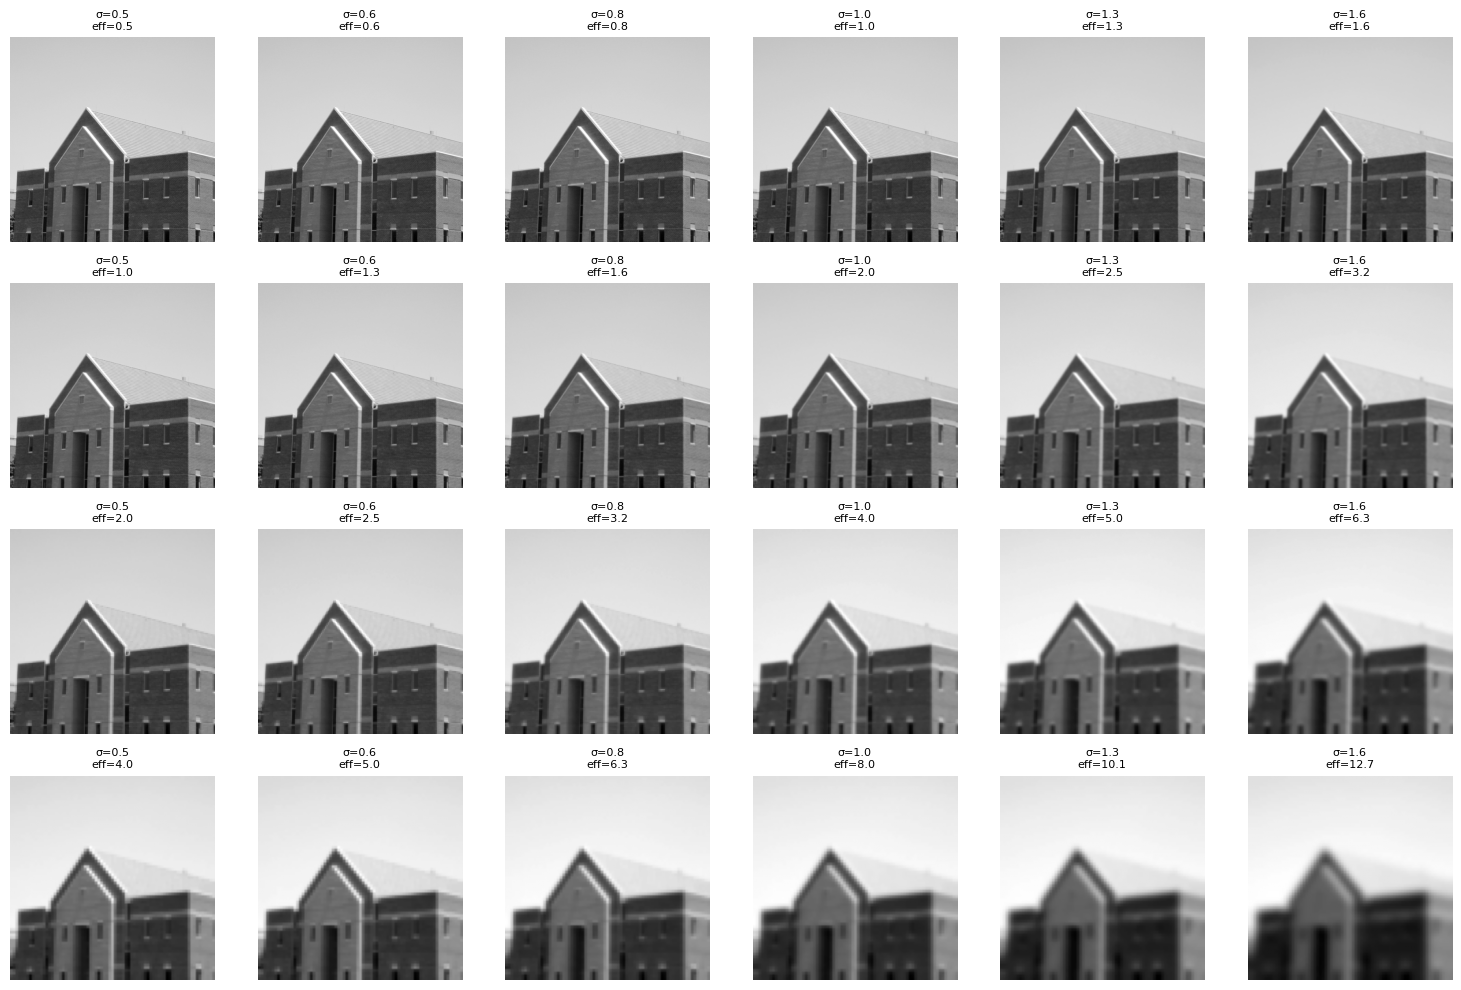

In [7]:
# Visualize your Gaussian pyramid
plot_gaussian_pyramid(images)

---
## Difference of Gaussians

### Background: DoG as LoG Approximation

The **Difference of Gaussians (DoG)** approximates the Laplacian of Gaussian (LoG), which is excellent for blob detection:

$$\text{DoG}(x,y,\sigma) = G(x,y,k\sigma) - G(x,y,\sigma) \approx (k-1)\sigma^2 \nabla^2 G$$

This acts as a **band-pass filter** that highlights structures at specific scales.

### Question 3: Compute Difference of Gaussians (0.06 points)

Compute DoG images by subtracting consecutive scales within each octave.

**Requirements:**
- For each octave, compute DoG[i] = Gaussian[i+1] - Gaussian[i]
- Convert images to float32 before subtraction to avoid overflow
- Return nested array of DoG images

In [8]:
def dog_levels(gaussian_images):
    """
    Compute Difference of Gaussians for all octaves.
    
    Args:
        gaussian_images: Output from generateGaussianImages()
                        gaussian_images[octave][scale]
    
    Returns:
        np.array: DoG images, shape (num_octaves, num_scales-1)
                  dog_images[octave][scale] = G[octave][scale+1] - G[octave][scale]
    
    Note:
        If we have 6 Gaussian images per octave, we get 5 DoG images.
    """
    dog_images = []
    for octave_images in gaussian_images:
        dog_images_in_octave = []
        for i in range(len(octave_images) - 1):
            img1 = octave_images[i].astype(np.float32)
            img2 = octave_images[i+1].astype(np.float32)
            dog = img2 - img1
            dog_images_in_octave.append(dog)
        dog_images.append(dog_images_in_octave)
    return np.array(dog_images, dtype=object)

# Test your implementation
dogs = dog_levels(images)
print(f"Generated DoG pyramid with {len(dogs)} octaves")
print(f"Each octave has {len(dogs[0])} DoG images")
print(f"DoG value range: [{dogs[0][0].min():.1f}, {dogs[0][0].max():.1f}]")

Generated DoG pyramid with 4 octaves
Each octave has 5 DoG images
DoG value range: [-11.0, 8.0]


#### Validation Checkpoint 3

In [9]:
# Validation for Question 3
assert len(dogs) == 4, f"Expected 4 octaves, got {len(dogs)}"
assert len(dogs[0]) == 5, f"Expected 5 DoG images per octave (6 Gaussian - 1), got {len(dogs[0])}"

# Check that DoG contains both positive and negative values
assert dogs[0][0].min() < 0, "DoG should have negative values"
assert dogs[0][0].max() > 0, "DoG should have positive values"

# Check data type
assert dogs[0][0].dtype in [np.float32, np.float64], "DoG should be floating point"

print("Question 3 validation passed!")
print(f"  DoG shapes: {[dogs[i][0].shape for i in range(len(dogs))]}")

Question 3 validation passed!
  DoG shapes: [(600, 600), (300, 300), (150, 150), (75, 75)]


#### Visualization: DoG Pyramid

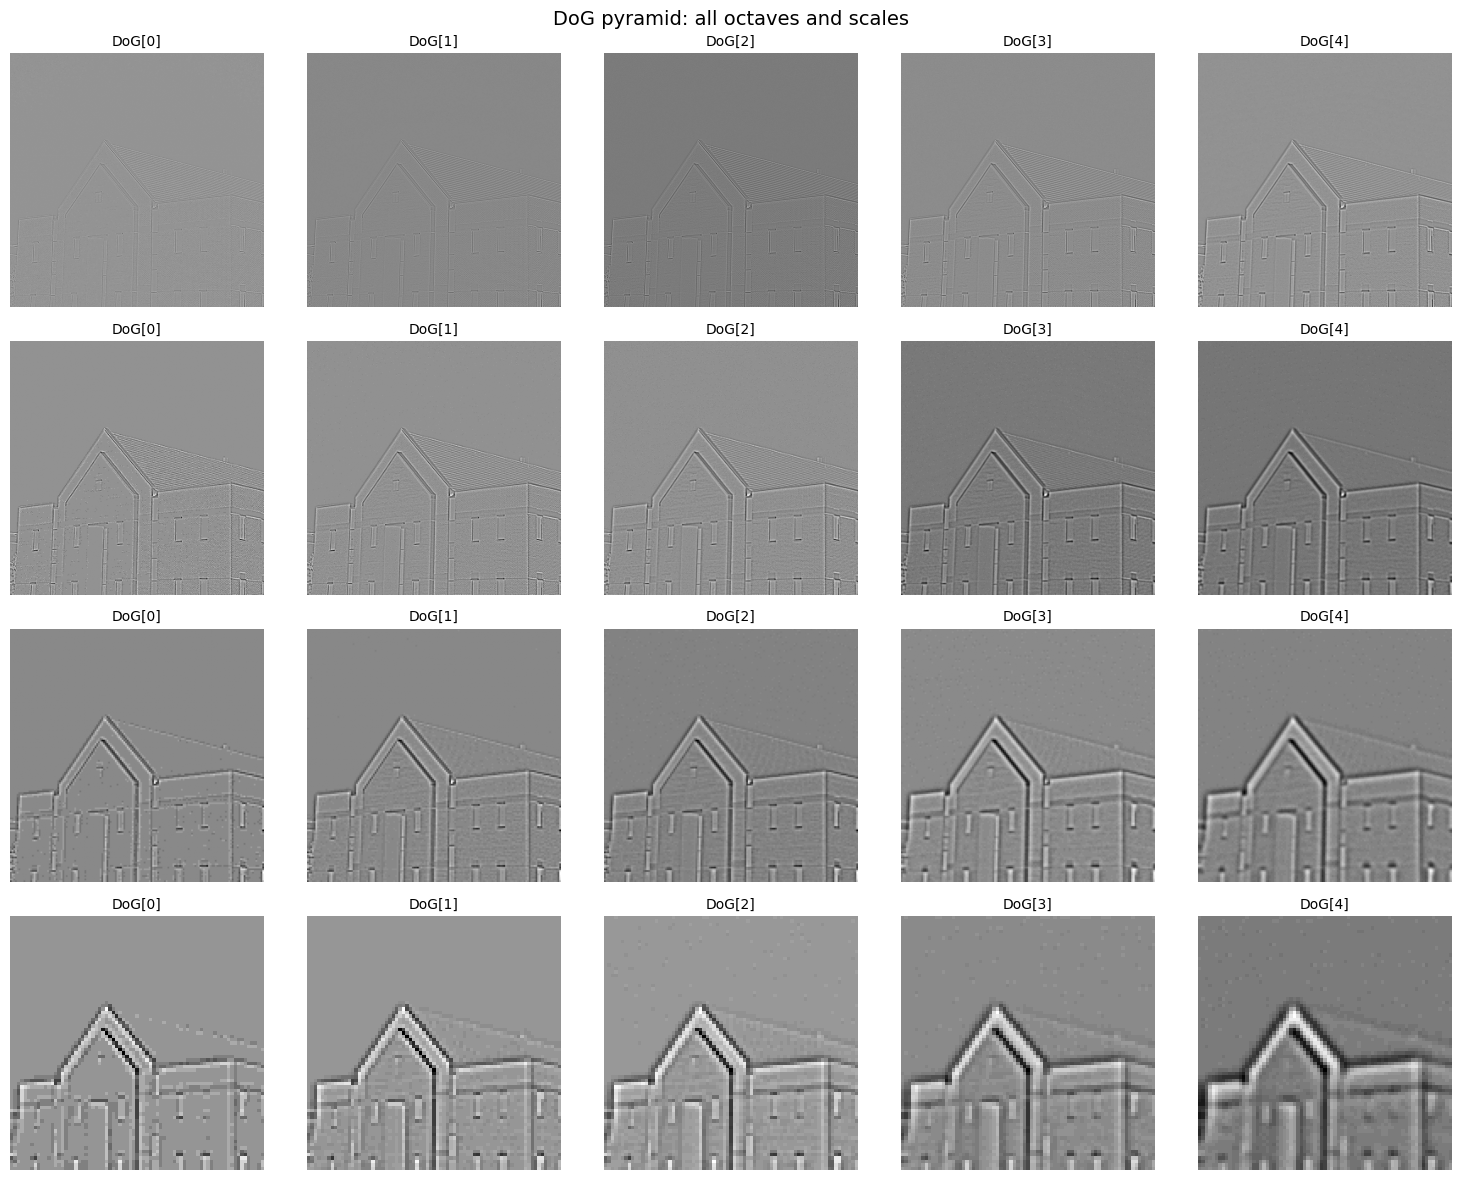

In [10]:
# Visualize DoG pyramid
visualize_all_dog_levels(dogs)

---
## Scale-Space Extrema Detection

### Background: 3D Extrema Detection

A keypoint is a point that is a **local maximum or minimum** in a 3×3×3 neighborhood:

```
Scale σ+1:    □ □ □
              □ □ □
              □ □ □

Scale σ:      □ □ □
              □ ● □    ← Check if ● is max/min of ALL 26 neighbors
              □ □ □

Scale σ-1:    □ □ □
              □ □ □
              □ □ □
```

**Why 26 neighbors?** 8 in current scale + 9 above + 9 below = 26

**Why skip first and last DoG?** We need a DoG image above and below to check extrema.

### Question 4: Find Scale-Space Extrema (0.10 points)

Detect keypoints as 3D local extrema in the DoG pyramid.

**Requirements:**
- For each octave, check DoG scales 1 through len(dog_octave)-2 (skip first and last)
- For each pixel (i, j), extract 3×3×3 cube of values
- Check if center pixel is maximum OR minimum of all 27 values in cube
- Apply contrast threshold: `abs(center_value) >= threshold`
- Skip pixels near image borders (distance < `border`)
- Scale coordinates back to original image size: multiply by 2^octave
- Return list of tuples: (x, y, octave, scale)

In [11]:
def findScaleSpaceExtrema(dog_images, threshold=5, border=5):
    """
    Find keypoints as 3D extrema in scale-space.
    
    Args:
        dog_images: DoG pyramid from dog_levels()
        threshold: Minimum absolute contrast to be considered a keypoint
        border: Pixels to skip at image edges
    
    Returns:
        list: Keypoints as (x, y, octave_idx, scale_idx) tuples
              Coordinates (x, y) are in original image space
    """
    keypoints = []

    for octave_idx, dog_octave in enumerate(dog_images):
        # We need 3 consecutive DoG images, so skip first and last
        for scale_idx in range(1, len(dog_octave) - 1):
            prev_img = dog_octave[scale_idx - 1]
            curr_img = dog_octave[scale_idx]
            next_img = dog_octave[scale_idx + 1]

            # Check each pixel (skip borders)
            for i in range(border, curr_img.shape[0] - border):
                for j in range(border, curr_img.shape[1] - border):

                    # Get center pixel value
                    center = curr_img[i, j]

                    # Skip low contrast
                    if abs(center) < threshold:
                        continue

                    # Extract 3x3x3 neighborhood
                    cube = np.array([])

                    cube = np.array([prev_img[i-1:i+2, j-1:j+2], 
                                    curr_img[i-1:i+2, j-1:j+2], 
                                    next_img[i-1:i+2, j-1:j+2]])

                    # Check if center is maximum or minimum of all 27 values
                    if center == cube.max() or center == cube.min():
                        scale_factor = 2 ** octave_idx
                        x = j * scale_factor
                        y = i * scale_factor
                        keypoints.append((x, y, octave_idx, scale_idx))
    return keypoints

# Test your implementation
keypoints = findScaleSpaceExtrema(dogs, threshold=7)
print(f"Found {len(keypoints)} keypoints")
if len(keypoints) > 0:
    print(f"First keypoint: x={keypoints[0][0]}, y={keypoints[0][1]}, octave={keypoints[0][2]}, scale={keypoints[0][3]}")

Found 9438 keypoints
First keypoint: x=523, y=348, octave=0, scale=1


#### Validation Checkpoint 4

In [12]:
# Validation for Question 4
assert len(keypoints) > 100, f"Expected many keypoints, got only {len(keypoints)}"
assert len(keypoints) < 10000, f"Too many keypoints ({len(keypoints)}), check threshold"

# Check keypoint format
x, y, o, s = keypoints[0]
assert 0 <= x < building.shape[1], "X coordinate out of bounds"
assert 0 <= y < building.shape[0], "Y coordinate out of bounds"
assert 0 <= o < 4, "Octave index out of range"
assert 1 <= s <= 3, "Scale index should be in middle range (not first or last DoG)"

print("Question 4 validation passed!")
print(f"  Keypoint distribution by octave: {[sum(1 for kp in keypoints if kp[2] == i) for i in range(4)]}")

Question 4 validation passed!
  Keypoint distribution by octave: [7713, 1149, 438, 138]


#### Visualization: Detected Keypoints

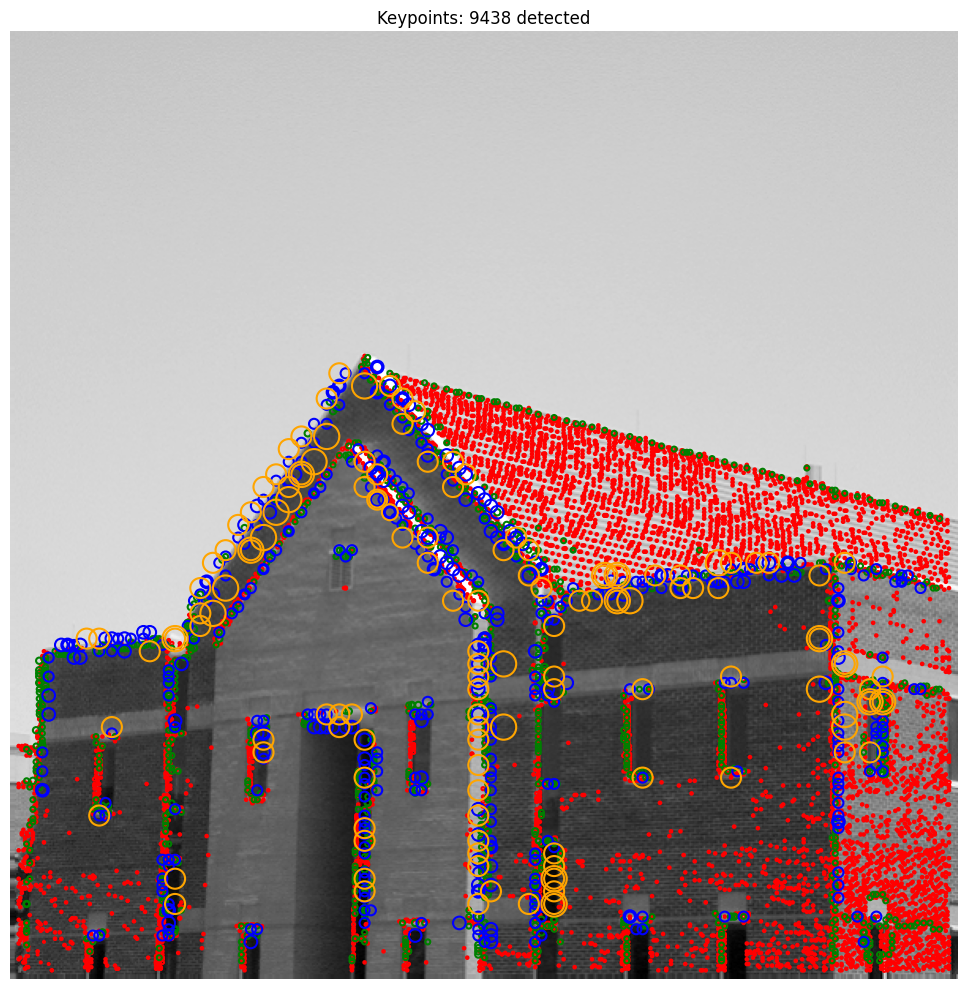

In [13]:
# Visualize keypoints on original image
visualize_keypoints(building, keypoints)

---
## Orientation Assignment

### Background: Rotation Invariance

To make SIFT rotation-invariant, we:
1. Compute image gradients (magnitude and direction)
2. Build a histogram of gradient orientations around each keypoint
3. Assign the dominant orientation as the keypoint's canonical orientation

Later, when computing descriptors, we'll rotate the sampling grid to align with this orientation.

### Question 5: Compute Image Gradients (0.05 points)

Compute gradient magnitude and orientation using Sobel operators.

**Requirements:**
- Use `cv2.Sobel()` to compute dx and dy derivatives
- Magnitude: `sqrt(dx² + dy²)`
- Orientation: `arctan2(dy, dx)` converted to degrees in range [0, 360)

In [14]:
def computeGradients(image):
    """
    Compute gradient magnitude and orientation for the entire image.
    
    Args:
        image: Grayscale image
    
    Returns:
        tuple: (magnitude, orientation)
               magnitude: Same shape as image, dtype float
               orientation: Same shape as image, values in [0, 360) degrees
    """
    dx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    dy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(dx**2 + dy**2)
    
    orientation_rad = np.arctan2(dy, dx)
    orientation_deg = np.degrees(orientation_rad)
    orientation = orientation_deg % 360
    return magnitude, orientation

# Test on a sample image
mag, ori = computeGradients(building)
print(f"Gradient magnitude range: [{mag.min():.1f}, {mag.max():.1f}]")
print(f"Gradient orientation range: [{ori.min():.1f}, {ori.max():.1f}]")

Gradient magnitude range: [0.0, 908.2]
Gradient orientation range: [0.0, 359.9]


#### Validation Checkpoint 5

In [15]:
# Validation for Question 5
assert mag.shape == building.shape, "Magnitude should have same shape as input"
assert ori.shape == building.shape, "Orientation should have same shape as input"
assert mag.min() >= 0, "Magnitude should be non-negative"
assert 0 <= ori.min() and ori.max() < 360, "Orientation should be in [0, 360)"

# Test on a simple gradient
test_img = np.zeros((100, 100), dtype=np.float32)
test_img[:, 50:] = 255  # Vertical edge
test_mag, test_ori = computeGradients(test_img)
edge_ori = test_ori[50, 50]
assert 350 <= edge_ori or edge_ori <= 10, f"Vertical edge should have ~0° orientation, got {edge_ori:.1f}"

print("Question 5 validation passed!")

Question 5 validation passed!


### Question 6: Compute Dominant Orientation (0.05 points)

Compute the dominant orientation for a keypoint by finding the peak in the orientation histogram.

**Requirements:**
- Use `computeHistogram` to build a 36-bin orientation histogram around the keypoint
- Find the bin with maximum value
- Convert bin index to angle (bin_index × 10°)
- Return the dominant orientation in degrees [0, 360)

In [16]:
def computeOrientation(magnitude, orientation, x, y, radius):
    """
    Compute dominant orientation for a keypoint.
    
    Args:
        magnitude: Gradient magnitude image
        orientation: Gradient orientation image
        x, y: Keypoint coordinates
        radius: Window radius (typically sigma * 3)
    
    Returns:
        float: Dominant orientation in degrees [0, 360)
    """
    hist = computeHistogram(magnitude, orientation, x, y, radius, num_bins=36, reference_angle=0)
    max_bin_index = np.argmax(hist)
    angle = max_bin_index * 10.0
    return angle

#### Validation Checkpoint 6-7

In [17]:
# Validation for Questions 6-7
test_hist = computeHistogram(mag, ori, 300, 300, radius=20, num_bins=36)
assert len(test_hist) == 36, f"Expected 36 bins, got {len(test_hist)}"
assert test_hist.sum() > 0, "Histogram should have non-zero values"

test_angle = computeOrientation(mag, ori, 300, 300, radius=20)
assert 0 <= test_angle < 360, f"Orientation should be in [0, 360), got {test_angle}"
assert test_angle % 10 == 0, f"With 36 bins, angle should be multiple of 10, got {test_angle}"

print("Questions 6-7 validation passed!")
print(f"  Test orientation at (300, 300): {test_angle}°")

Questions 6-7 validation passed!
  Test orientation at (300, 300): 320.0°


---
## SIFT Descriptor

### Background: Rotation-Invariant Descriptor

The SIFT descriptor is a **128-dimensional vector** (4×4 cells × 8 orientation bins).

**Key insight for rotation invariance:**
1. Rotate the sampling grid by the keypoint's dominant orientation
2. Compute orientations relative to the keypoint angle

This ensures the same descriptor is computed regardless of image rotation.

### Compute SIFT Descriptor

Given your previous functions we will now create the full descritpor, a 128-D descriptor using rotation-aligned sampling.

**What it does:**
- Divides window of size `2r × 2r` into 4×4 = 16 cells
- For each cell, computes 8-bin orientation histogram (relative to keypoint angle)
- **Rotates sampling coordinates** by keypoint angle:
  - `x_rot = cos(θ) * x_rel - sin(θ) * y_rel`
  - `y_rot = sin(θ) * x_rel + cos(θ) * y_rel`
- Concatenates all 16 histograms → 128 values
- Normalizes to unit length
- Returns None if keypoint too close to boundary

In [18]:
def computeDescriptor(magnitude, orientation, x, y, r, keypoint_angle):
    """
    Compute 128-dimensional SIFT descriptor with improved sampling.

    Improvements over basic version:
    - Gaussian weighting based on distance from keypoint center
    - Denser sampling with subpixel positions
    - Trilinear interpolation for distributing contributions
    """
    x, y = int(x), int(y)
    r = int(r)

    # Check bounds with margin
    margin = int(r * 1.5)
    if y - margin < 0 or y + margin >= magnitude.shape[0] or x - margin < 0 or x + margin >= magnitude.shape[1]:
        return None

    num_cells = 4
    num_bins = 8

    # Descriptor window is 2r × 2r, divided into 4×4 cells
    # Each cell is (r/2) × (r/2)
    hist_width = r / 2.0  # Width of each histogram cell

    angle_rad = np.radians(keypoint_angle)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)

    # Initialize 4×4×8 descriptor array
    desc_array = np.zeros((num_cells, num_cells, num_bins))

    # Gaussian weighting: sigma = descriptor_window_width / 2
    # This weights samples near the keypoint higher
    gauss_sigma = r

    # Sample densely within the descriptor window
    # Use 0.5 pixel steps for better coverage
    sample_range = int(r * 1.4)  # Sample slightly beyond window

    for dy in np.arange(-sample_range, sample_range, 0.5):
        for dx in np.arange(-sample_range, sample_range, 0.5):

            # Rotate sample point by keypoint angle
            dx_rot = cos_a * dx - sin_a * dy
            dy_rot = sin_a * dx + cos_a * dy

            # Absolute pixel position
            px = x + dx_rot
            py = y + dy_rot

            # Check bounds
            px_int, py_int = int(round(px)), int(round(py))
            if px_int < 0 or px_int >= magnitude.shape[1] or py_int < 0 or py_int >= magnitude.shape[0]:
                continue

            # Compute position in descriptor coordinates
            # Normalize to [-2, 2] where each cell is 1 unit
            xf = dx / hist_width + (num_cells / 2.0) - 0.5
            yf = dy / hist_width + (num_cells / 2.0) - 0.5

            # Skip if outside descriptor window
            if xf < -1 or xf >= num_cells or yf < -1 or yf >= num_cells:
                continue

            # Gaussian weight based on distance from keypoint
            dist_sq = dx**2 + dy**2
            weight = np.exp(-dist_sq / (2 * gauss_sigma**2))

            # Get gradient at this position
            mag = magnitude[py_int, px_int]
            ori = (orientation[py_int, px_int] - keypoint_angle) % 360

            # Apply Gaussian weight
            mag_weighted = mag * weight

            # Compute orientation bin (0-7)
            obin = ori / 45.0

            # Trilinear interpolation: distribute contribution to neighboring cells and bins
            xi, yi = int(np.floor(xf)), int(np.floor(yf))
            oi = int(np.floor(obin)) % num_bins

            # Fractional parts for interpolation
            xfrac = xf - xi
            yfrac = yf - yi
            ofrac = obin - int(np.floor(obin))

            # Distribute to 2×2×2 neighboring histogram bins
            for dy_offset in range(2):
                yy = yi + dy_offset
                if yy < 0 or yy >= num_cells:
                    continue
                y_weight = yfrac if dy_offset == 1 else (1 - yfrac)

                for dx_offset in range(2):
                    xx = xi + dx_offset
                    if xx < 0 or xx >= num_cells:
                        continue
                    x_weight = xfrac if dx_offset == 1 else (1 - xfrac)

                    for do_offset in range(2):
                        oo = (oi + do_offset) % num_bins
                        o_weight = ofrac if do_offset == 1 else (1 - ofrac)

                        contribution = mag_weighted * x_weight * y_weight * o_weight
                        desc_array[yy, xx, oo] += contribution

    # Flatten to 128-D vector
    descriptor = desc_array.flatten()

    # Normalize
    norm = np.linalg.norm(descriptor)
    if norm > 0:
        descriptor = descriptor / norm

        # Threshold large values to 0.2 and renormalize (illumination invariance)
        descriptor = np.clip(descriptor, 0, 0.2)
        norm = np.linalg.norm(descriptor)
        if norm > 0:
            descriptor = descriptor / norm

    return descriptor

#### Validation Checkpoint

In [19]:
# Validation for Question 8
test_desc = computeDescriptor(mag, ori, 300, 300, r=20, keypoint_angle=45)

assert test_desc is not None, "Descriptor should not be None for valid keypoint"
assert len(test_desc) == 128, f"Expected 128-D descriptor, got {len(test_desc)}"
assert abs(np.linalg.norm(test_desc) - 1.0) < 0.01, "Descriptor should be normalized"
assert test_desc.min() >= 0, "Descriptor values should be non-negative"

# Test rotation invariance (approximately)
desc_0 = computeDescriptor(mag, ori, 300, 300, r=20, keypoint_angle=0)
desc_45 = computeDescriptor(mag, ori, 300, 300, r=20, keypoint_angle=45)
# Descriptors should be different (different rotation)
diff = np.linalg.norm(desc_0 - desc_45)
assert diff > 0.1, "Descriptors at different angles should be different"

print("Question 8 validation passed!")
print(f"  Descriptor norm: {np.linalg.norm(test_desc):.3f}")
print(f"  Descriptor range: [{test_desc.min():.3f}, {test_desc.max():.3f}]")

Question 8 validation passed!
  Descriptor norm: 1.000
  Descriptor range: [0.000, 0.265]


---
### Question 7: Analyze Descriptor Behavior (0.20 points)

Now that you've implemented the complete SIFT descriptor, let's analyze how gradients and descriptors behave at different image locations.

This exercise demonstrates:
- How gradient orientation relates to image structure
- Why descriptor histograms look different at edges vs corners vs uniform regions
- What information SIFT actually encodes

**Task:** Run the visualization below on a checkerboard pattern and analyze the results.Compare the results with the clean image and the noisy image. What are the differences you visualise.

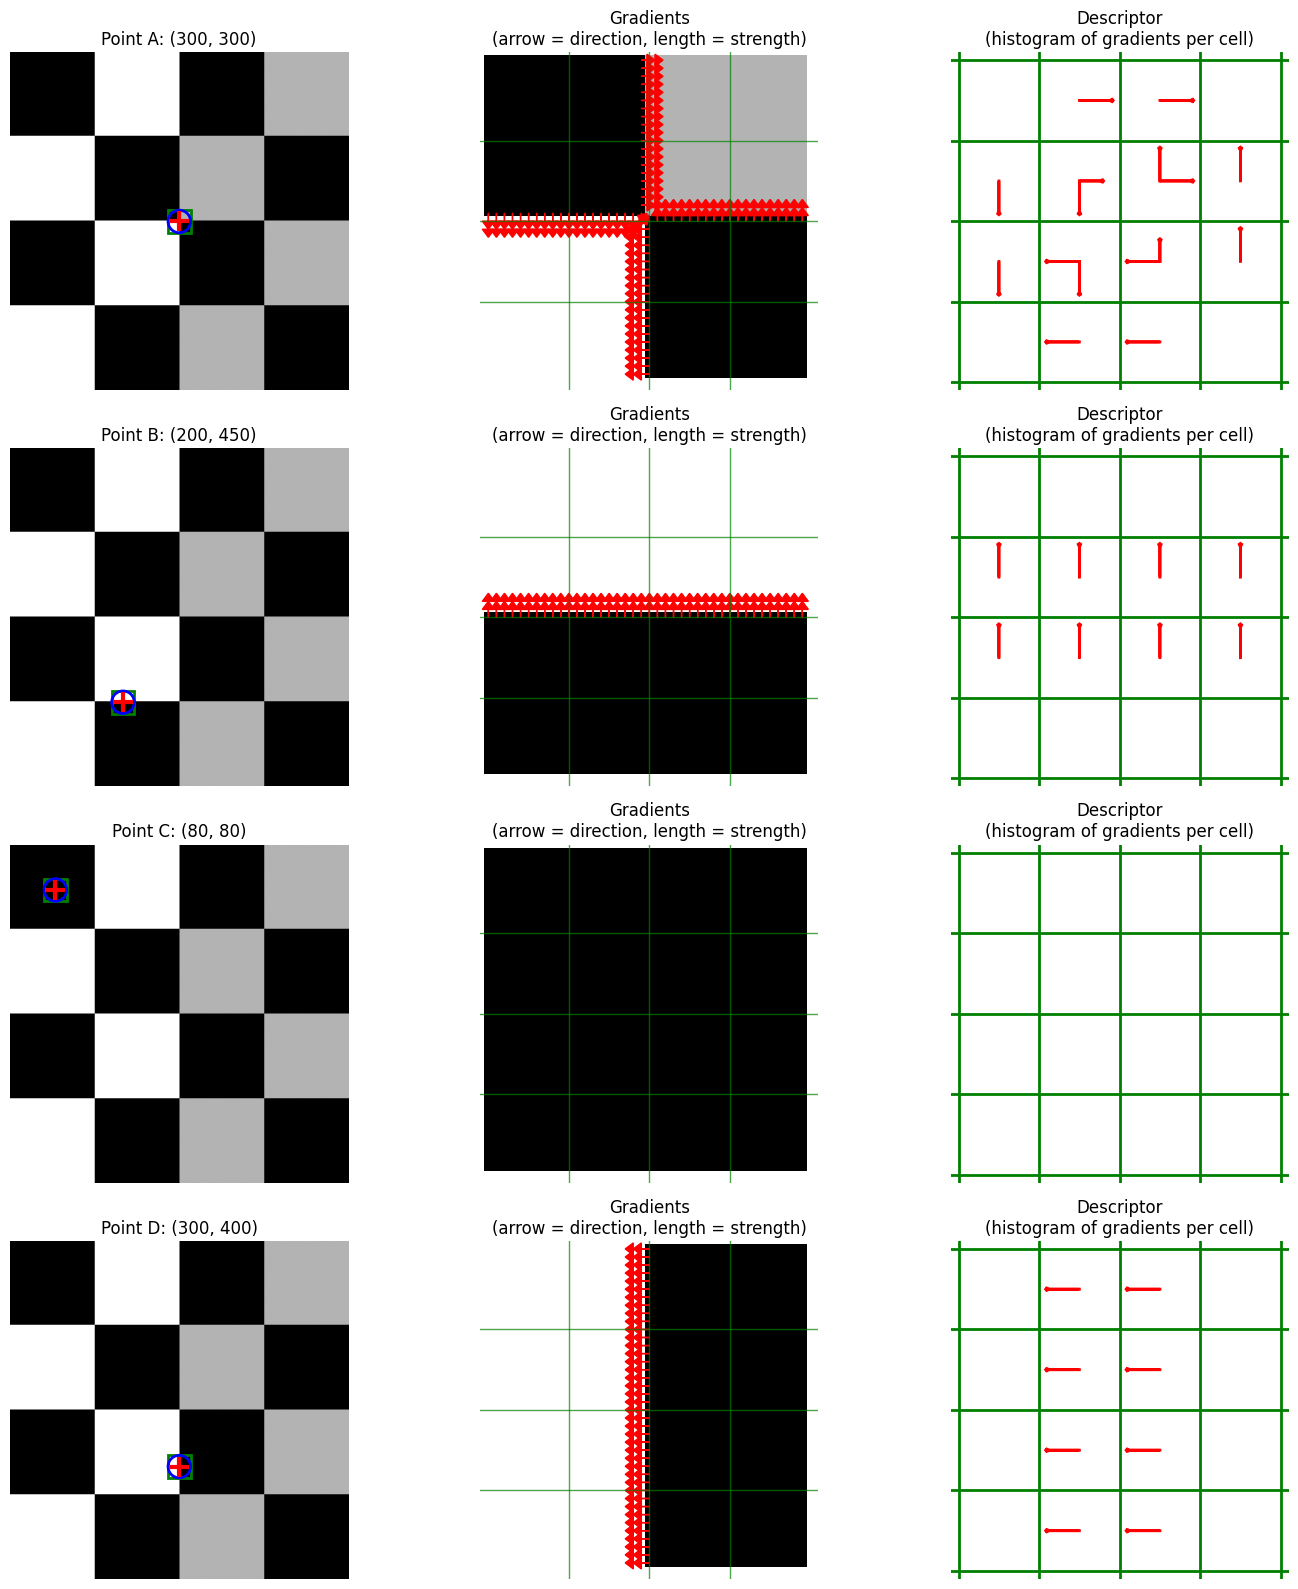

In [20]:
# Load checkerboard image
checkerboard_clean = cv2.imread('checkerboard-clean.tif', cv2.IMREAD_GRAYSCALE)
checkerboard_noisy = cv2.imread('checkerboard-noisy.tif', cv2.IMREAD_GRAYSCALE)
# Visualize gradients and descriptors at 4 different points
descriptor_exercise_with_gradients(checkerboard_clean, computeGradients)

#### Analysis Questions

For each of the 4 points (A, B, C, D) shown above, answer:

**Point A:**
1. What gradient patterns do you observe? (direction and strength)
2. What does the descriptor histogram show? Which orientation bins are strongest?

**Point B:**
1. How do the gradients differ from Point A?
2. Why does the descriptor histogram look this way?

**Point C:**
1. What is special about the gradient pattern here?
2. How is the descriptor different from Points A and B?
3. Would this be a good or bad keypoint? Why?

**Point D:**
1. Compare the gradients to Points A, B, and C
2. What does the descriptor encode about this location?
3. How does rotation invariance work for this point?

**General:**
- Which points would make the best SIFT keypoints? Why?
- What would happen to these descriptors if the image was rotated 45°?
- Why are descriptors computed in a 4×4 grid rather than a single histogram?
- Compared with the noisy version, what are the key differences and why?

**Your answers:**
- Point A:
     - The gradients point from the black squares towards the white squares. The strength (magnitude) is high at the boundaries and zero elsewhere.
    - The descriptor shows histograms with strong peaks in two distinct orientation bins separated by 90°. The 4x4 grid spatially separates these, showing horizontal gradients in some cells and vertical gradients in others.

- Point B:
    - The gradients are aligned in only one dominant direction (perpendicular to the edge). Unlike Point A, there is no variation in orientation; all arrows point roughly the same way.
    - The histogram is uniaxial. Most bins are empty, with a massive spike in just one or two adjacent orientation bins representing the edge's normal direction 
- Point C:
    - The gradients have near-zero magnitude. There are no significant arrows because there is no intensity change inside the solid color square.
    - The descriptor is empty. It lacks the strong peaks seen in A and B.
    - Bad. It is a featureless region. It cannot be uniquely localized (it looks identical to any other part of the white/black square) and provides no information for matching.
- Point D:
    - its identical to B but the arrows point sideways. 
    - its an vertical edge
    - If the image rotates, the gradient arrows here would rotate. However, SIFT calculates the dominant orientation and rotates the descriptor grid to align with it. Thus, the relative descriptor values would remain approximately the same, ensuring the point matches even if the scene is turned.

- General observations:
    - Best SIFT Keypoints: Points A and D (Corners). They represent scale-space extrema with strong gradients in multiple directions. This makes them uniquely identifiable and easy to localize precisely in both X and Y coordinates.
    - Why 4x4 Grid? To capture spatial structure. A single histogram would only tell you "there are some horizontal and vertical edges here," but it wouldn't tell you where they are. The 4x4 grid preserves the spatial layout of the gradients.


---
## Complete SIFT Implementation

### Integrate Everything

Combine all steps to detect keypoints with orientations and descriptors. This will follow the same steps as your `findScaleSpaceExtrema` but with the `descriptors` and `dominant angle` calculation (there is no question here, if you managed to do `findScaleSpaceExtrema` you just need to update with your solution)

**What it does:**
- Uses your `findScaleSpaceExtrema` logic
- For each extremum, computes gradients on the corresponding Gaussian image
- Computes orientation using `computeOrientation`
- Computes descriptor using `computeDescriptor`
- Returns list of tuples: (x, y, octave, scale, angle, descriptor)

In [23]:
def findScaleSpaceExtremaWithDescriptors(dog_images, gaussian_images,
                                         sigma=0.5, num_intervals=3,
                                         threshold=5, border=5):
    """
    Find keypoints with orientation and descriptors.
    """
    k = 2 ** (1 / num_intervals)
    keypoints = []

    for octave_idx, dog_octave in enumerate(dog_images):
        for scale_idx in range(1, len(dog_octave) - 1):
            prev_img = dog_octave[scale_idx - 1]
            curr_img = dog_octave[scale_idx]
            next_img = dog_octave[scale_idx + 1]

            gauss_img = gaussian_images[octave_idx][scale_idx]

            # Compute gradients ONCE per scale
            magnitude, orientation = computeGradients(gauss_img)

            for i in range(border, curr_img.shape[0] - border):
                for j in range(border, curr_img.shape[1] - border):

                    center = curr_img[i, j]

                    # Skip low contrast
                    if abs(center) < threshold:
                        continue

                    # Extract 3x3x3 neighborhood
                    slice_prev = prev_img[i-1:i+2, j-1:j+2]
                    slice_curr = curr_img[i-1:i+2, j-1:j+2]
                    slice_next = next_img[i-1:i+2, j-1:j+2]
                    
                    cube = np.array([slice_prev, slice_curr, slice_next])

                    if center == cube.max() or center == cube.min():
                        relative_sigma = sigma * (k ** scale_idx)

                        # Step 1: Orientation (one histogram → one angle)
                        radius_orientation = relative_sigma * 3 #Original SIFT sigma value, it allows to have stable orientations
                        angle = computeOrientation(magnitude, orientation, j, i, radius_orientation)

                        # Step 2: Descriptor (4×4 histograms → 128 numbers)
                        radius_descriptor = relative_sigma * 8 #Original SIFT sigma value, it allows capture an area that is descriptive enough
                        descriptor = computeDescriptor(magnitude, orientation, j, i, radius_descriptor, angle)

                        if descriptor is not None:
                            #TODO now that we have the cube, our keypoint will consist of the position on the original image the idx of the octave and idx of the scale
                            #TODO we need to then scale the pixel position to the original coordinates
                            scale_factor = 2 ** octave_idx
                            x = j * scale_factor #TODO
                            y = i * scale_factor #TODO
                            keypoints.append((x, y, octave_idx, scale_idx, angle, descriptor))

    return keypoints

# Test complete SIFT implementation
sift_keypoints = findScaleSpaceExtremaWithDescriptors(dogs, images, sigma=0.5, num_intervals=3)
print(f"Detected {len(sift_keypoints)} SIFT keypoints with descriptors")
if len(sift_keypoints) > 0:
    x, y, o, s, angle, desc = sift_keypoints[0]
    print(f"First keypoint: ({x}, {y}), octave={o}, scale={s}, angle={angle:.1f}°, descriptor shape={desc.shape}")

Detected 20144 SIFT keypoints with descriptors
First keypoint: (228, 211), octave=0, scale=1, angle=320.0°, descriptor shape=(128,)


#### Validation Checkpoint

In [24]:
assert len(sift_keypoints) > 50, f"Expected many keypoints, got {len(sift_keypoints)}"

# Check format
x, y, o, s, angle, desc = sift_keypoints[0]
assert len(desc) == 128, f"Descriptor should be 128-D, got {len(desc)}"
assert 0 <= angle < 360, f"Angle should be in [0, 360), got {angle}"
assert abs(np.linalg.norm(desc) - 1.0) < 0.01, "Descriptor should be normalized"

print("Question 9 validation passed!")
print(f"  Total keypoints: {len(sift_keypoints)}")
print(f"  Sample descriptor: {desc[:8]}...")

Question 9 validation passed!
  Total keypoints: 20144
  Sample descriptor: [0.28134598 0.03131063 0.00757547 0.00809734 0.0161804  0.00718451
 0.02492073 0.04803152]...


#### Visualization: Keypoints with Orientation

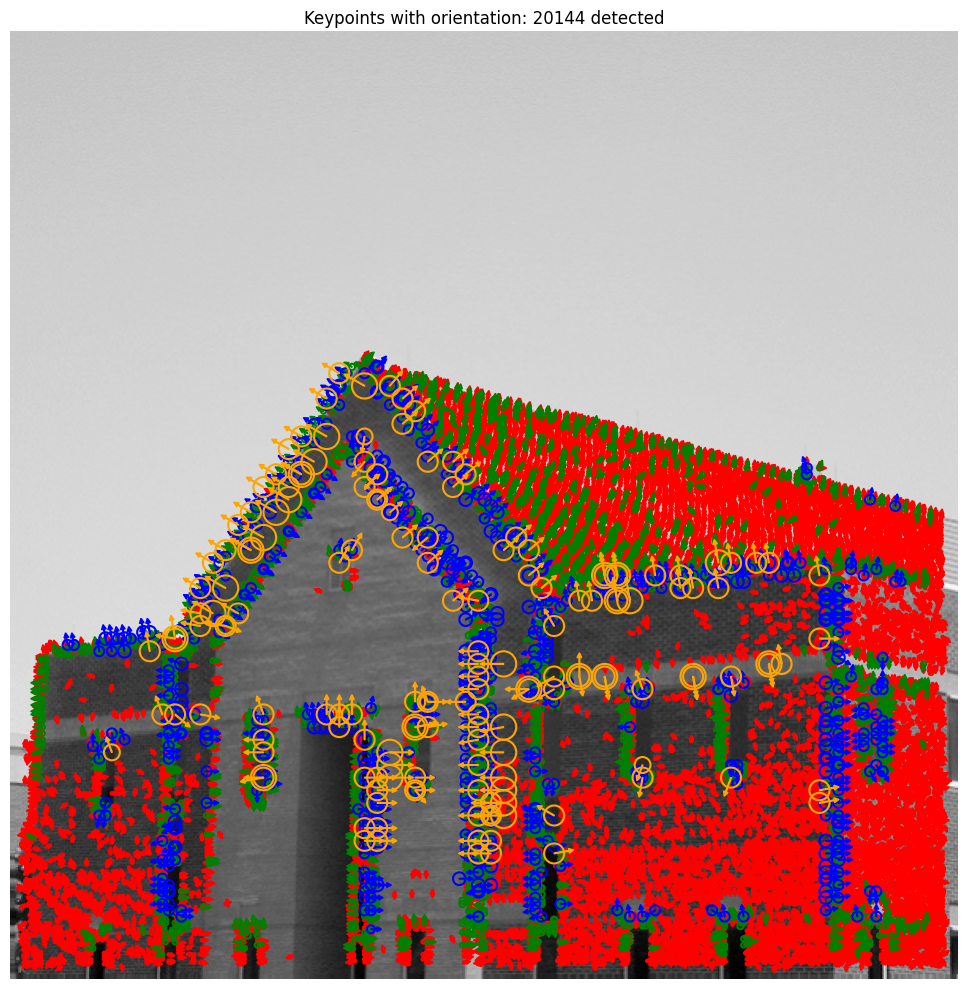

In [25]:
# Visualize keypoints with orientation arrows
visualize_keypoints_with_orientation(building, sift_keypoints)

## Matching and Comparison

Test your SIFT implementation against OpenCV on rotation and matching tasks.

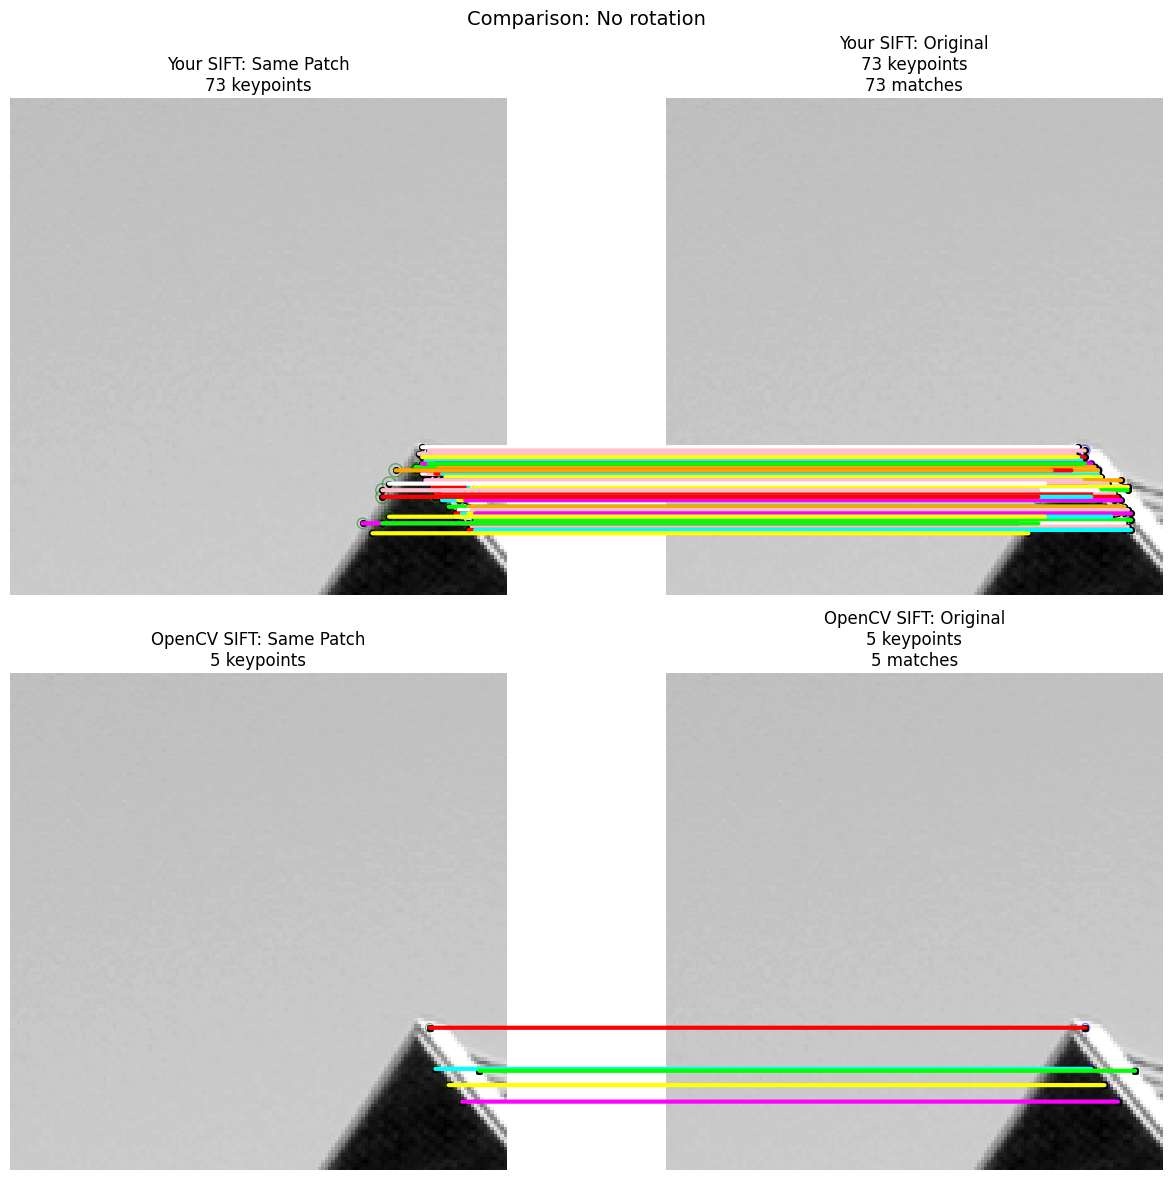

In [26]:
# Compare with OpenCV: no rotation
compare_matching_with_opencv(building, generateGaussianImages, generateGaussianKernels,
                             dog_levels, findScaleSpaceExtremaWithDescriptors,
                             sigma=0.5, rotate=False)

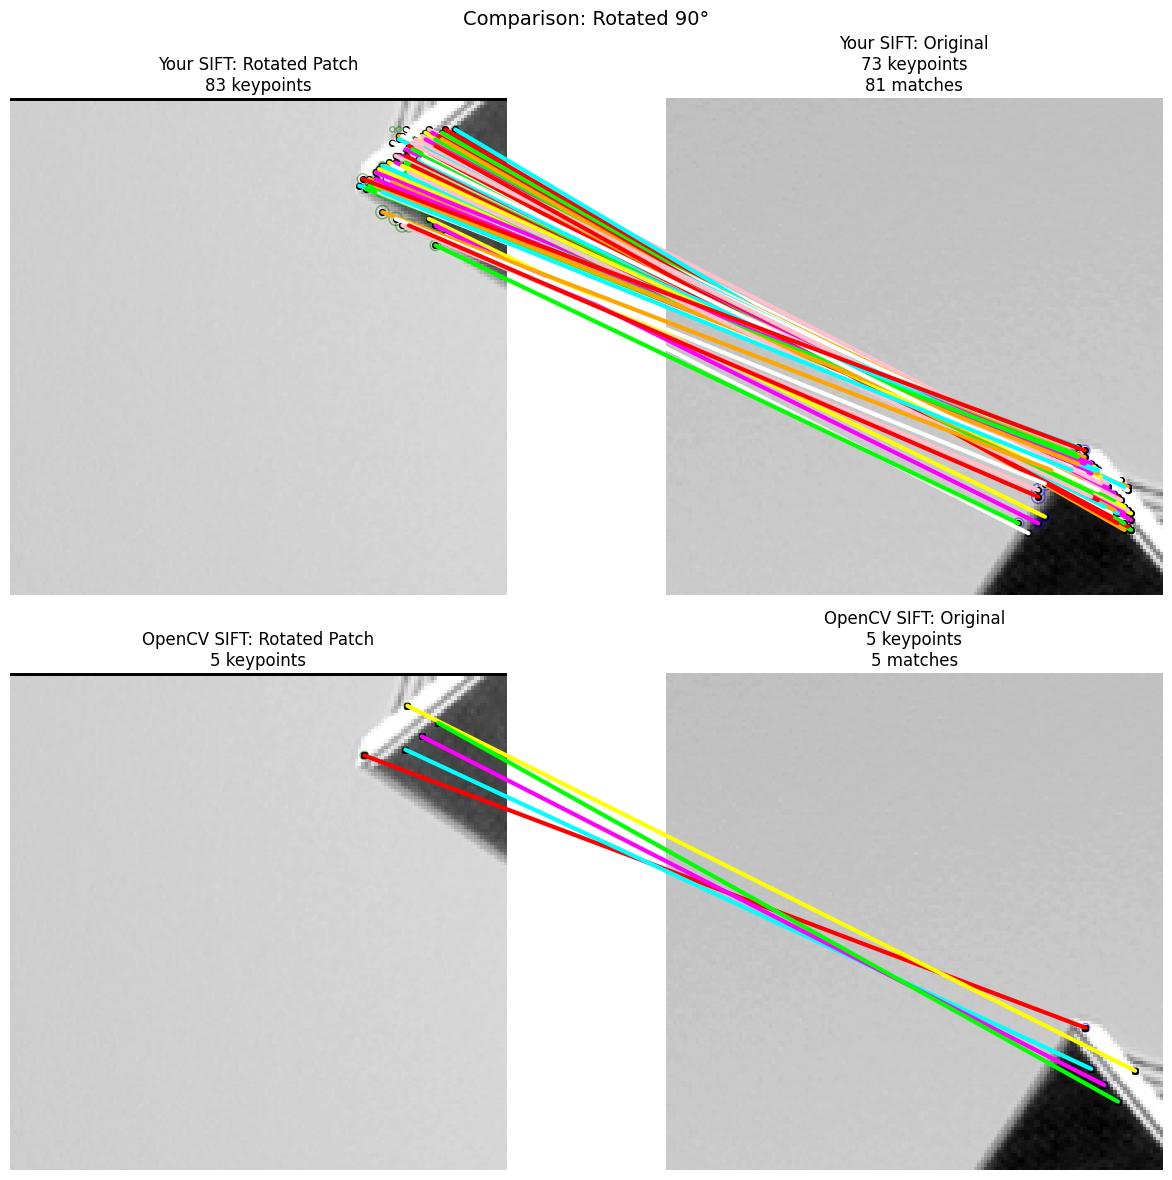

In [27]:
# Compare with OpenCV: 90° rotation
compare_matching_with_opencv(building, generateGaussianImages, generateGaussianKernels,
                             dog_levels, findScaleSpaceExtremaWithDescriptors,
                             sigma=0.5, rotate=True, rotation_angle=90)

---

## Question 8: SIFT Robustness Analysis (0.17 points)

Test how well SIFT handles different image transformations by analyzing match quality. (remember, the openCV implementation is optimise to get the best results, we have implemented the main building blocks of SIFT but there is much more behind the scenes we haven't implemented. Having worse results than OpenCV is expected)

**Transformations to test:**
- Rotation: 30°, 45°, 90°, 180°
- Scale: 0.5× , 1.5× , 2.0×
- Illumination: +50 brightness, ×0.5 darker
- Noise: Gaussian noise (σ=10, σ=25)
- Blur: Gaussian blur (σ=3, σ=7)

**Part 1: Run transformation tests**

Execute the code below to test all transformations and observe match ratios.

**Part 2: Complete analysis table**

Fill in the table with your observations:

| Transformation | Match Ratio | Pass/Fail (>0.15) | Why it succeeds/fails |
|----------------|-------------|-------------------|----------------------|
| Rotation 30°   | 0.230            | ✓                 | Your explanation     |
| Rotation 45°   | 0.092            | ✗                 | Your explanation     |
| Rotation 90°   | 0.995            | ✓                 | Your explanation     |
| Rotation 180°  | 0.993            | ✓                 | Your explanation     |
| Scale 0.5×     | 0.116            | ✗                 | Your explanation     |
| Scale 1.5×     | 0.236            | ✓                 | Your explanation     |
| Scale 2.0×     | 0.738            | ✓                 | Your explanation     |
| Bright +50     | 0.807            | ✓                 | Your explanation     |
| Dark ×0.5      | 1.049            | ✓                 | Your explanation     |
| Noise σ=10     | 0.181            | ✓                 | Your explanation     |
| Noise σ=25     | 0.070            | ✗                 | Your explanation     |
| Blur σ=3       | 1.064            | ✓                 | Your explanation     |
| Blur σ=7       | 40.429           | ✓                 | Your explanation     |

**Part 3: General analysis**

Answer these questions based on your results:
1. Which transformation type does SIFT handle BEST? Why?
- Illumination changes (Brightness/Darkness) and Grid-Aligned Rotations (90°/180°). SIFT descriptors are constructed from gradients, meaning adding a constant brightness cancels out mathematically. Contrast scaling is handled by vector normalization. Rotations by 90°/180° involve no interpolation loss, preserving the exact pixel values and gradients.
2. Which transformation type does SIFT handle WORST? Why?
- Heavy Noise and Downscaling. Noise: SIFT relies entirely on local pixel-to-pixel differences. Heavy noise creates "fake" gradients, causing the dominant orientation assignment to flip randomly, which rotates the entire descriptor incorrectly. Downscaling: You cannot match what isn't there. Shrinking an image removes data; if the texture details are lost, the descriptors cannot be computed.
3. What is the fundamental limitation that causes SIFT to fail?
- The fundamental limitation is its reliance on accurate local gradients. If a transformation distorts the local gradient directions by more than the bin width of the histograms, the values shift into wrong bins, and the descriptor distance becomes too large to match.
4. For what types of applications would SIFT be suitable vs unsuitable?
- Suitable: Object recognition in static scenes, image stitching (panoramas), and 3D reconstruction where lighting might change or the camera moves (scale/rotation).
Unsuitable: 
 Low-light/Noisy environments, Non-rigid objects.


In [28]:
# Define transformations to test
# You can add more transformations or modify parameters!
transformations_to_test = [
    ("Rotation 30°", lambda img: apply_rotation(img, 30)),
    ("Rotation 45°", lambda img: apply_rotation(img, 45)),
    ("Rotation 90°", lambda img: apply_rotation(img, 90)),
    ("Rotation 180°", lambda img: apply_rotation(img, 180)),
    ("Scale 0.5×", lambda img: apply_scale(img, 0.5)),
    ("Scale 1.5×", lambda img: apply_scale(img, 1.5)),
    ("Scale 2.0×", lambda img: apply_scale(img, 2.0)),
    ("Brightness +50", lambda img: apply_brightness(img, 50)),
    ("Darkness ×0.5", lambda img: (img * 0.5).astype(np.uint8)),
    ("Noise σ=10", lambda img: apply_noise(img, 10)),
    ("Noise σ=25", lambda img: apply_noise(img, 25)),
    ("Blur σ=3", lambda img: apply_blur(img, 3)),
    ("Blur σ=7", lambda img: apply_blur(img, 7)),
]

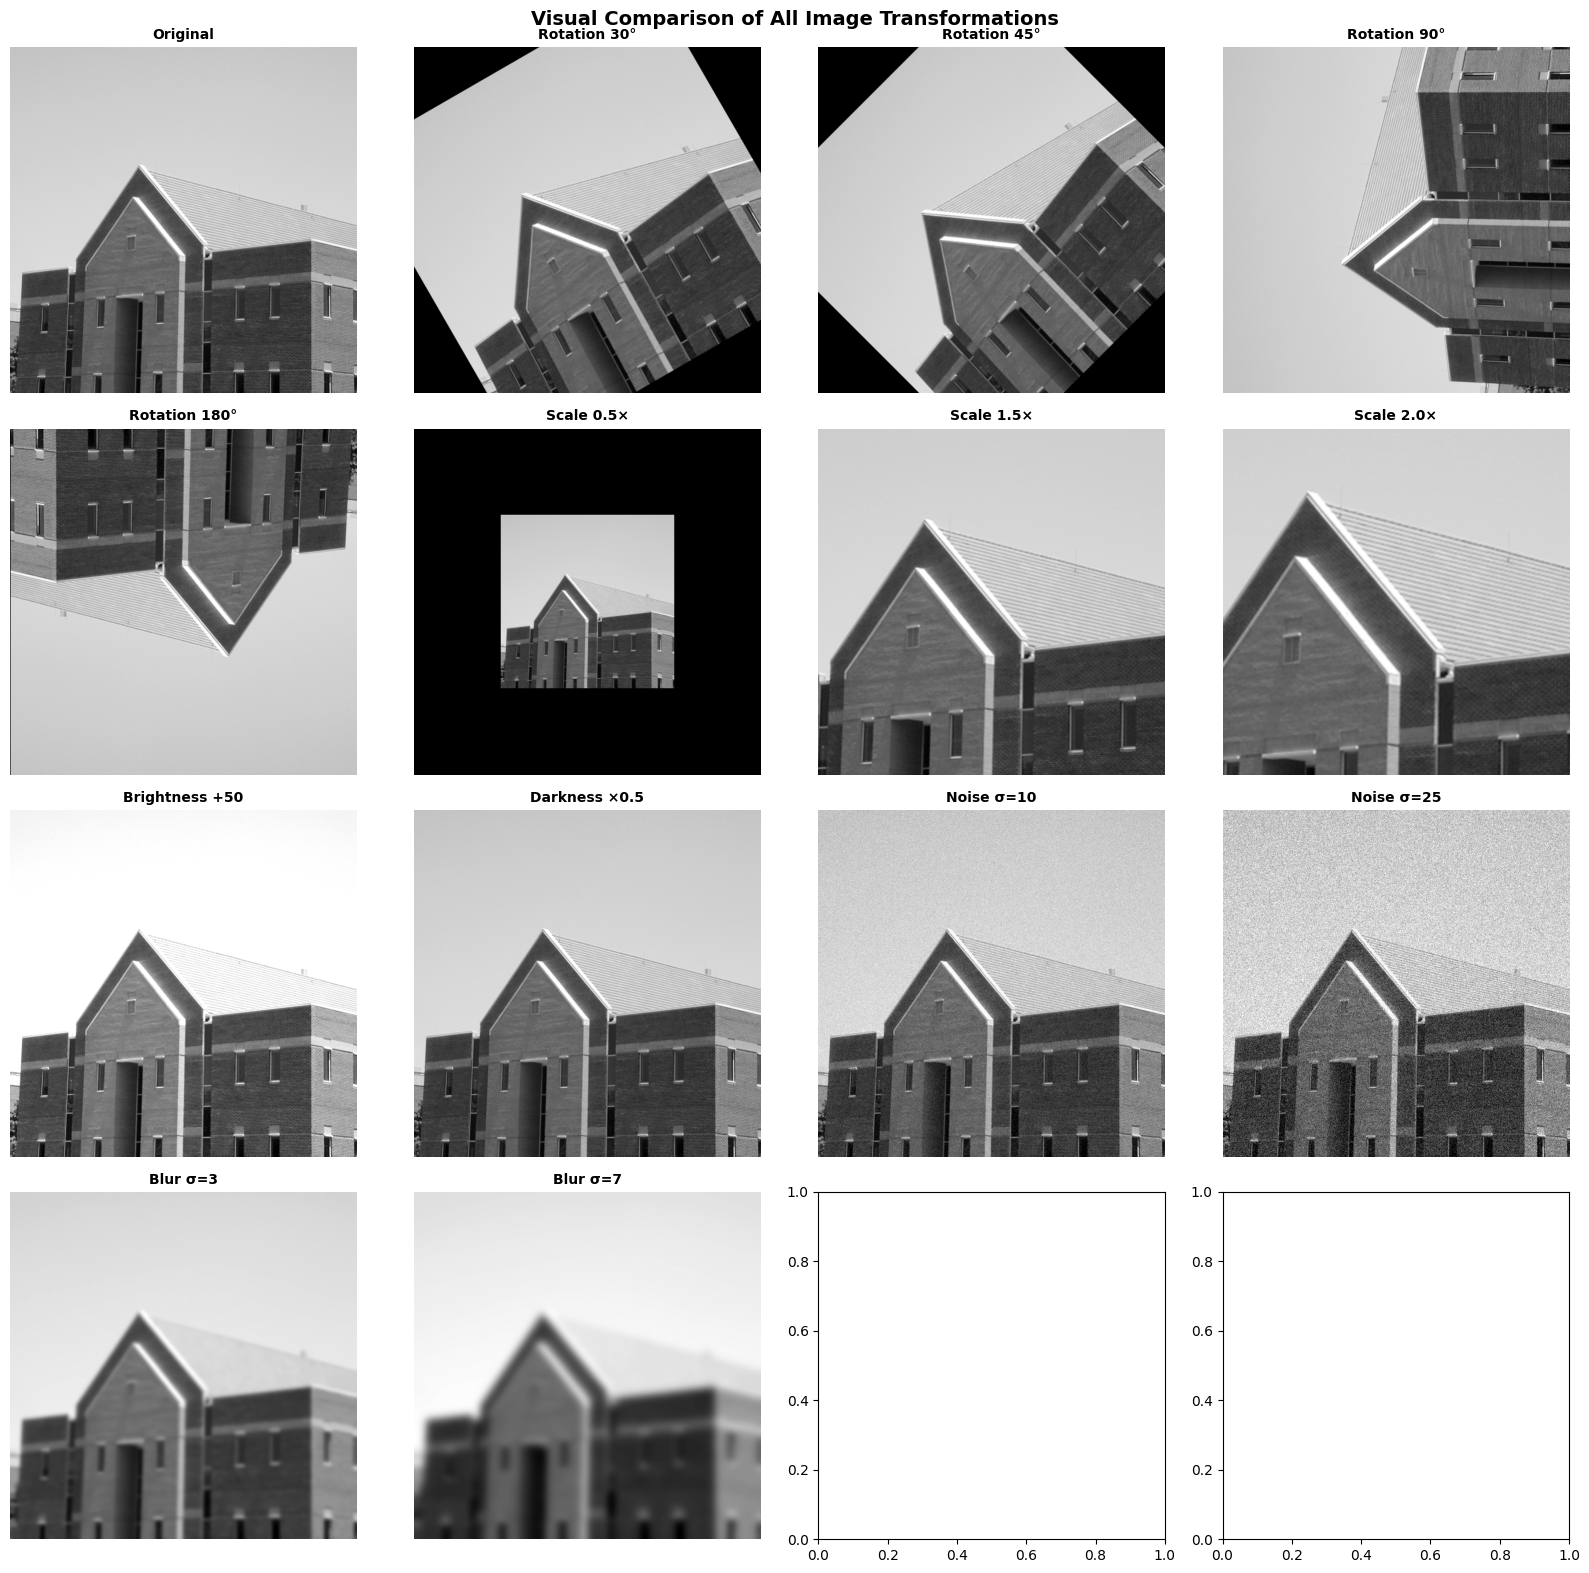


Part 2: Testing SIFT Robustness (Your Implementation vs OpenCV)
----------------------------------------------------------------------

Computing keypoints for original image...
Original - Your SIFT: 5430 keypoints
Original - OpenCV SIFT: 598 keypoints

Testing transformations...
Transformation            Your SIFT            OpenCV SIFT          Difference     
Rotation 30°              0.230 ✓               0.469 ✓               -0.238
Rotation 45°              0.092 ✗               0.453 ✓               -0.362
Rotation 90°              0.995 ✓               0.925 ✓               +0.070
Rotation 180°             0.993 ✓               0.892 ✓               +0.100
Scale 0.5×                0.116 ✗               0.500 ✓               -0.384
Scale 1.5×                0.236 ✓               0.229 ✓               +0.007
Scale 2.0×                0.738 ✓               0.162 ✓               +0.575
Brightness +50            0.807 ✓               0.923 ✓               -0.116
Darkness ×0.5     

In [29]:
# First, visualize sample transformations
visualize_transformations_custom(building)  # Show first 9

print("\nPart 2: Testing SIFT Robustness (Your Implementation vs OpenCV)")
print("-"*70)

results_yours, results_opencv = test_sift_robustness_with_opencv_custom(
    building,
    generateGaussianImages,
    generateGaussianKernels,
    dog_levels,
    findScaleSpaceExtremaWithDescriptors,
    sigma=0.5,
    num_intervals=3,
    threshold=8
)

---
## Face Recognition with Deep Learning (Extra)

Compare SIFT (handcrafted features) with modern CNN-based embeddings.

### Load Face Dataset

In [ ]:
from sklearn.datasets import fetch_lfw_pairs

lfw_pairs = fetch_lfw_pairs(subset='test', color=True, resize=4.0)

pairs = lfw_pairs.pairs
labels = lfw_pairs.target

print(f"Number of pairs: {len(pairs)}")
print(f"Positive pairs (same person): {labels.sum()}")
print(f"Negative pairs (different person): {len(labels) - labels.sum()}")

### Setup CNN Model

In [ ]:
import torch
from facenet_pytorch import InceptionResnetV1

# Load pretrained VGGFace2 model
model = InceptionResnetV1(pretrained='vggface2').eval()

def preprocess_face(face):
    """
    Preprocess face for CNN.
    
    Args:
        face: numpy array (H, W, 3) with values 0-1 or 0-255
    
    Returns:
        tensor: (1, 3, 160, 160) normalized tensor
    """
    if face.max() <= 1.0:
        face = (face * 255).astype(np.uint8)
    else:
        face = face.astype(np.uint8)
    
    face_resized = cv2.resize(face, (160, 160))
    tensor = torch.from_numpy(face_resized).permute(2, 0, 1).float()
    tensor = (tensor - 127.5) / 128.0
    tensor = tensor.unsqueeze(0)
    
    return tensor

### Question 10 (extra): Compute CNN Face Similarity

Implement face similarity using CNN embeddings.

**Requirements:**
- Preprocess both faces using `preprocess_face()`
- Extract 512-D embeddings using `model(tensor)`
- Compute cosine similarity: `F.cosine_similarity(emb1, emb2)`
- Map from [-1, 1] to [0, 1]: `(similarity + 1) / 2`

In [ ]:
def cnn_face_similarity(face1, face2):
    """
    Compute similarity between two faces using CNN embeddings.
    
    Args:
        face1, face2: Face images as numpy arrays
    
    Returns:
        float: Similarity score in [0, 1]
    """
    pass

# Test on sample faces
test_sim_same = cnn_face_similarity(pairs[0][0], pairs[0][1])
test_sim_diff = cnn_face_similarity(pairs[500][0], pairs[500][1])

print(f"Similarity (same person): {test_sim_same:.3f}")
print(f"Similarity (different person): {test_sim_diff:.3f}")

### Compare All Three Methods

In [ ]:
def compute_similarity_sift(face1, face2):
    """SIFT-based face similarity."""
    if len(face1.shape) == 3:
        gray1 = cv2.cvtColor(face1, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(face2, cv2.COLOR_RGB2GRAY)
    else:
        gray1, gray2 = face1.copy(), face2.copy()

    if gray1.max() <= 1.0:
        gray1 = (gray1 * 255).astype(np.float32)
        gray2 = (gray2 * 255).astype(np.float32)

    sigma, num_intervals, threshold = 0.5, 3, 5
    kernels = generateGaussianKernels(sigma, num_intervals)

    gaussian1 = generateGaussianImages(gray1, kernels, num_octaves=4)
    dog1 = dog_levels(gaussian1)
    kp1 = findScaleSpaceExtremaWithDescriptors(dog1, gaussian1, sigma, num_intervals, threshold)

    gaussian2 = generateGaussianImages(gray2, kernels, num_octaves=4)
    dog2 = dog_levels(gaussian2)
    kp2 = findScaleSpaceExtremaWithDescriptors(dog2, gaussian2, sigma, num_intervals, threshold)

    if len(kp1) == 0 or len(kp2) == 0:
        return 0.0

    desc1 = np.array([kp[5] for kp in kp1])
    desc2 = np.array([kp[5] for kp in kp2])

    good = 0
    for d1 in desc1:
        distances = np.linalg.norm(desc2 - d1, axis=1)
        sorted_idx = np.argsort(distances)
        if len(sorted_idx) > 1 and distances[sorted_idx[0]] < 0.75 * distances[sorted_idx[1]]:
            good += 1

    return good / min(len(kp1), len(kp2))


def compute_similarity_opencv(face1, face2):
    """OpenCV SIFT-based face similarity."""
    if len(face1.shape) == 3:
        gray1 = cv2.cvtColor(face1, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(face2, cv2.COLOR_RGB2GRAY)
    else:
        gray1, gray2 = face1.copy(), face2.copy()

    if gray1.max() <= 1.0:
        gray1 = (gray1 * 255).astype(np.uint8)
        gray2 = (gray2 * 255).astype(np.uint8)
    else:
        gray1 = gray1.astype(np.uint8)
        gray2 = gray2.astype(np.uint8)

    sift = cv2.SIFT_create()
    kp1, desc1 = sift.detectAndCompute(gray1, None)
    kp2, desc2 = sift.detectAndCompute(gray2, None)

    if desc1 is None or desc2 is None or len(desc1) < 2 or len(desc2) < 2:
        return 0.0

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)
    
    good = 0
    for match in matches:
        if len(match) >= 2:
            m, n = match
            if m.distance < 0.75 * n.distance:
                good += 1
    
    return good / min(len(kp1), len(kp2)) if min(len(kp1), len(kp2)) > 0 else 0.0


def compare_methods(pairs, labels, num_samples=100):
    """Compare Your SIFT, OpenCV SIFT, and CNN."""
    from sklearn.metrics import roc_curve, auc

    pos_indices = np.where(labels == 1)[0]
    neg_indices = np.where(labels == 0)[0]

    n_each = num_samples // 2
    np.random.seed(42)
    selected_pos = np.random.choice(pos_indices, size=min(n_each, len(pos_indices)), replace=False)
    selected_neg = np.random.choice(neg_indices, size=min(n_each, len(neg_indices)), replace=False)
    selected_indices = np.concatenate([selected_pos, selected_neg])

    methods = {
        'Your SIFT': compute_similarity_sift,
        'OpenCV SIFT': compute_similarity_opencv,
        'CNN (VGGFace2)': cnn_face_similarity
    }

    results = {}

    for name, method in methods.items():
        print(f"\nEvaluating {name}...")
        sims = []
        for i, idx in enumerate(selected_indices):
            face1, face2 = pairs[idx]
            sim = method(face1, face2)
            sims.append(sim)
            if (i + 1) % 20 == 0:
                print(f"  Processed {i + 1}/{len(selected_indices)}")

        sims = np.array(sims)
        gt = labels[selected_indices]

        fpr, tpr, _ = roc_curve(gt, sims)
        auc_score = auc(fpr, tpr)

        results[name] = {
            'auc': auc_score,
            'mean_same': sims[gt == 1].mean(),
            'mean_diff': sims[gt == 0].mean(),
            'fpr': fpr,
            'tpr': tpr
        }

    print(f"\n{'='*60}")
    print(f"{'Method':<20} {'AUC':<10} {'Same':<10} {'Diff':<10}")
    print(f"{'='*60}")
    for name, r in results.items():
        print(f"{name:<20} {r['auc']:<10.3f} {r['mean_same']:<10.3f} {r['mean_diff']:<10.3f}")
    print(f"{'='*60}")

    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    for name, r in results.items():
        plt.plot(r['fpr'], r['tpr'], linewidth=2, label=f"{name} (AUC={r['auc']:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Face Verification ROC Curves', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.show()

    return results

results = compare_methods(pairs, labels, num_samples=100)

### Final Analysis Questions (Extra)

1. **Which method performed best? Why?**
   - Your answer:

2. **What are the advantages of SIFT over CNNs?**
   - Your answer:

3. **What are the advantages of CNNs over SIFT?**
   - Your answer:

4. **When would you choose SIFT vs CNN embeddings?**
   - Your answer: